**Import Libraries**

In [1]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import plotly.express as ex
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report, roc_curve, roc_auc_score, RocCurveDisplay,
                             precision_recall_curve, average_precision_score,
                             make_scorer, fbeta_score
                             )
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeRegressor
from sklearn.base import BaseEstimator, TransformerMixin 
from sklearn.inspection import permutation_importance

%matplotlib inline
background_color = "#f6f6f6"


**Load Dataset**

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.sample(5)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4906,72696,Female,53.0,0,0,Yes,Private,Urban,70.51,54.1,never smoked,0
3725,24202,Male,63.0,0,0,Yes,Private,Rural,78.23,34.8,never smoked,0
4872,13583,Female,5.0,0,0,No,children,Rural,88.44,18.0,Unknown,0
679,68131,Female,27.0,0,0,No,Private,Rural,149.95,25.9,never smoked,0
689,5892,Female,55.0,1,0,Yes,Private,Rural,99.82,34.2,never smoked,0


**Check Dataset Size**

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 5110
Number of columns: 12


**Display Columns and it data type**

In [4]:
df.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

**Explore data type with object have what atribute inside**

In [5]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')

we would like to clean up the Other column , let see how many column contain gender == other

In [6]:
other_rows = df[df['gender'] == 'Other']
print("Rows containing 'Other':")
print(other_rows)

Rows containing 'Other':
         id gender   age  hypertension  heart_disease ever_married work_type  \
3116  56156  Other  26.0             0              0           No   Private   

     Residence_type  avg_glucose_level   bmi   smoking_status  stroke  
3116          Rural             143.33  22.4  formerly smoked       0  


Well ,only 1 , so we will drop it

In [7]:
df.drop(df[df['gender'] == 'Other'].index, inplace=True)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5109
Number of columns: 12


**Check missing value**

In [8]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

**BMI Imputer as a Pipeline Step (fit on training data only, inside the pipeline)**


In [9]:
class BMIDecisionTreeImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = X.copy()

        bmi_features = X[['age', 'gender']]
        bmi_target = X['bmi']

        # Only use rows with known BMI
        mask = bmi_target.notna()

        self.bmi_model = Pipeline([
            ('scale', StandardScaler()),
            ('tree', DecisionTreeRegressor(random_state=42))
        ])

        self.bmi_model.fit(
            bmi_features.loc[mask],
            bmi_target.loc[mask]
        )

        return self

    def transform(self, X):
        X = X.copy()

        missing_mask = X['bmi'].isna()

        if missing_mask.any():
            predicted_bmi = self.bmi_model.predict(
                X.loc[missing_mask, ['age', 'gender']]
            )
            X.loc[missing_mask, 'bmi'] = predicted_bmi

        return X


In [10]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

**Check Duplicate Data**

In [11]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


# Explore Data Analysis

In [12]:
fig = ex.pie(df, names='stroke', color_discrete_sequence=['#17BECF', '#FFC20A'])
fig.update_layout(title='<b>Proportion Of Stroke Samples<b>')
fig.show()


we can cearly see the dataset is unbalanced , so we will oversampling it using SMOTE approach in the futere

**Age Distribution**

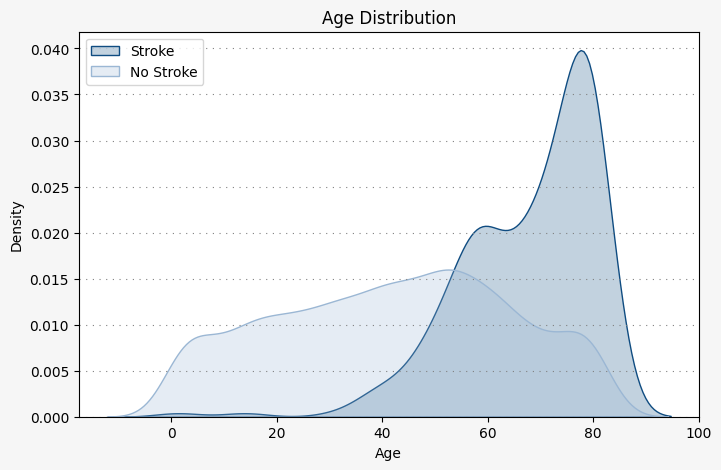

In [13]:
str_only = df[df['stroke'] == 1]
no_str_only = df[df['stroke'] == 0]

fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

ax.grid(color='gray', linestyle=':', axis='y', dashes=(1,5))

positive = pd.DataFrame(str_only["age"])
negative = pd.DataFrame(no_str_only["age"])

sns.kdeplot(positive["age"], ax=ax, color="#0f4c81", fill=True, label="Stroke")
sns.kdeplot(negative["age"], ax=ax, color="#9bb7d4", fill=True, label="No Stroke")

ax.set_title("Age Distribution")
ax.set_xlabel("Age")
ax.set_ylabel("Density")
ax.legend()

plt.show()


**Smoking Status**

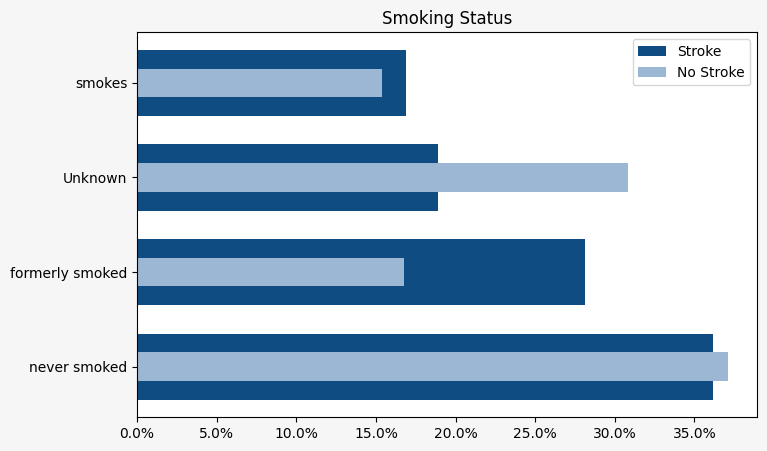

In [14]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["smoking_status"].value_counts())
positive["Percentage"] = (positive["count"] / positive["count"].sum()) * 100

negative = pd.DataFrame(no_str_only["smoking_status"].value_counts())
negative["Percentage"] = (negative["count"] / negative["count"].sum()) * 100

ax.barh(positive.index, positive["Percentage"], color="#0f4c81", height=0.7, label="Stroke")
ax.barh(negative.index, negative["Percentage"], color="#9bb7d4", height=0.3, label="No Stroke")

ax.set_title("Smoking Status")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()

plt.show()


**Gender**

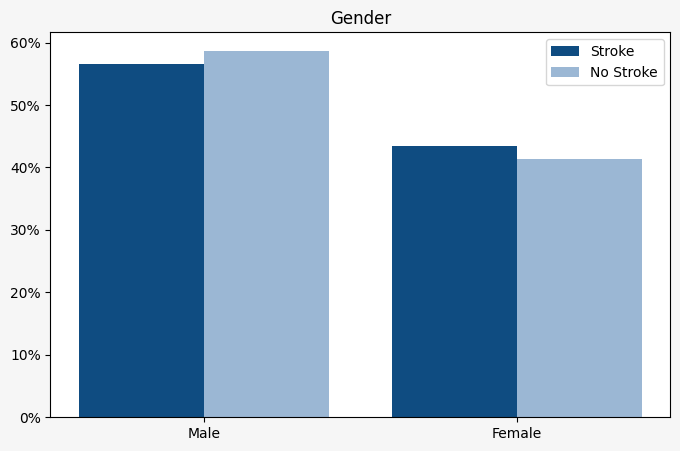

In [15]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["gender"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["gender"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["Male","Female"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Gender")
ax.legend()

plt.show()


**Heart Disease**

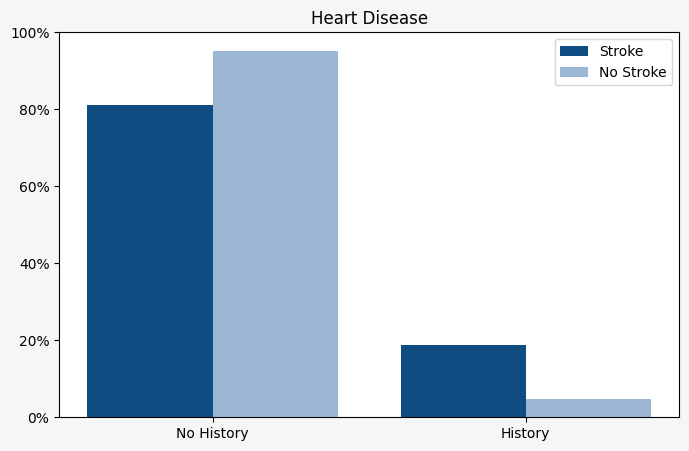

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["heart_disease"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["heart_disease"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Heart Disease")
ax.legend()

plt.show()


**Average Glucose Level**

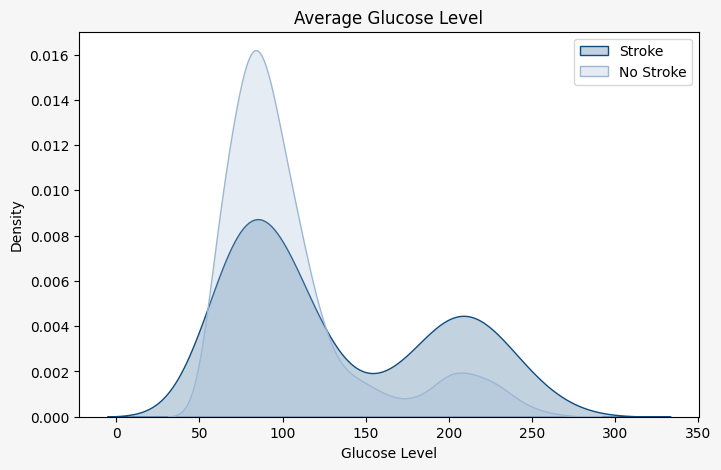

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["avg_glucose_level"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["avg_glucose_level"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("Average Glucose Level")
ax.set_xlabel("Glucose Level")
ax.legend()

plt.show()


**BMI**

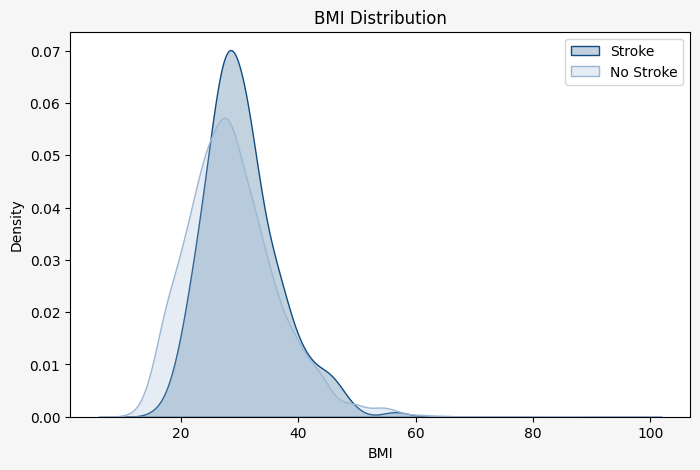

In [18]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

sns.kdeplot(str_only["bmi"], fill=True, color="#0f4c81", label="Stroke")
sns.kdeplot(no_str_only["bmi"], fill=True, color="#9bb7d4", label="No Stroke")

ax.set_title("BMI Distribution")
ax.set_xlabel("BMI")
ax.legend()

plt.show()


**Work Type**

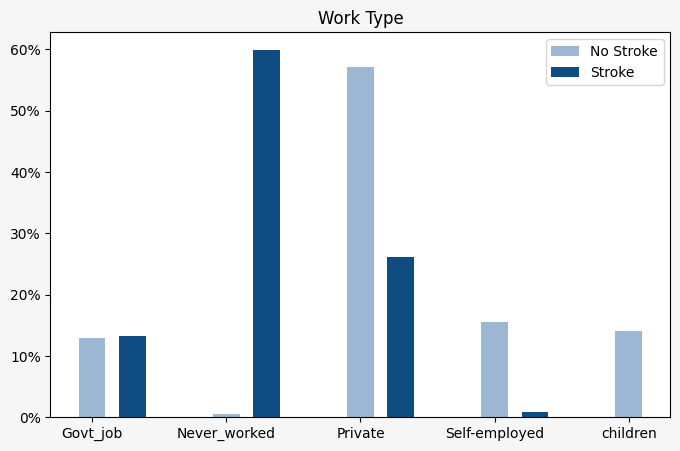

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["work_type"].value_counts()).sort_index()
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["work_type"].value_counts()).sort_index()
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

ax.bar(negative.index, negative["Percentage"], width=0.2, color="#9bb7d4", label="No Stroke")
ax.bar(np.arange(len(positive))+0.3, positive["Percentage"], width=0.2, color="#0f4c81", label="Stroke")

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Work Type")
ax.legend()

plt.show()


**Hypertension**

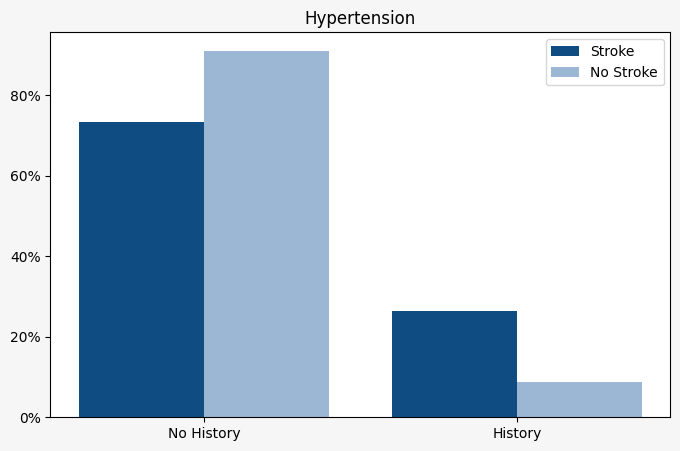

In [20]:
fig, ax = plt.subplots(figsize=(8,5))
fig.patch.set_facecolor(background_color)

positive = pd.DataFrame(str_only["hypertension"].value_counts())
positive["Percentage"] = positive["count"] / positive["count"].sum() * 100

negative = pd.DataFrame(no_str_only["hypertension"].value_counts())
negative["Percentage"] = negative["count"] / negative["count"].sum() * 100

x = np.arange(len(positive))

ax.bar(x, positive["Percentage"], width=0.4, color="#0f4c81", label="Stroke")
ax.bar(x+0.4, negative["Percentage"], width=0.4, color="#9bb7d4", label="No Stroke")

ax.set_xticks(x+0.2)
ax.set_xticklabels(["No History","History"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Hypertension")
ax.legend()

plt.show()


**Remove ID Column**

The id column is only a patient identifier.
It does not represent a meaningful health characteristic.

In [21]:
df = df.drop('id', axis=1)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**Find unique data in each column**

In [22]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')


# Label Encoding

**ever_married**

In [23]:
df['ever_married'] = df['ever_married'].replace({'Yes':1,'No':0})

In [24]:
print(f'{'ever_married'} : {df['ever_married'].unique()}')

ever_married : [1 0]


**convert into integer**

In [25]:
df.ever_married=pd.to_numeric(df.ever_married)

**gender**

In [26]:
df['gender'] = df['gender'].replace({'Male':1,'Female':0})

In [27]:
print(f'{'gender'} : {df['gender'].unique()}')

gender : [1 0]


**convert into integer**

In [28]:
df.gender=pd.to_numeric(df.gender)

# One Hot Encoding

In [29]:
for column in df:
    if df[column].dtypes=='object':
        print(f'{column} : {df[column].unique()}')

**now we will use one hot encoding for work type ,resisdent type and smoking status**

In [30]:
df=pd.get_dummies(data=df,columns=['work_type','Residence_type','smoking_status'])
df.sample(5)

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
2331,1,37.0,0,0,1,91.68,32.4,0,False,False,True,False,False,True,False,False,True,False,False
3992,1,39.0,0,0,1,125.11,24.9,0,False,False,True,False,False,True,False,False,True,False,False
4605,1,58.0,0,0,1,127.40,35.8,0,False,False,True,False,False,False,True,False,True,False,False
2175,0,2.0,0,0,0,155.14,13.7,0,False,False,False,False,True,True,False,True,False,False,False
1034,1,75.0,0,0,1,105.63,28.2,0,False,False,True,False,False,False,True,False,False,False,True


In [31]:
df.dtypes


gender                              int64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
work_type_Govt_job                   bool
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
Residence_type_Rural                 bool
Residence_type_Urban                 bool
smoking_status_Unknown               bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

**Splitting, Imputing, and Scaling to Prevent Data Leakage**

In [32]:
# 1. Prepare features/target
X = df.drop('stroke', axis='columns')
y = df['stroke']

# 2. Train/test split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verify shapes
X_train.shape, X_test.shape

((4087, 18), (1022, 18))

# Pipeline: Training Baseline SVM (Without SMOTE)

Training Baseline SVM (Without SMOTE)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Best parameters for Baseline SVM: {'svm__kernel': 'sigmoid', 'svm__gamma': 'scale', 'svm__C': 100}

BASELINE SVM EVALUATION (NO SMOTE)
Accuracy : 0.9022
Precision: 0.0833
Recall   : 0.1000
F1 Score : 0.0909
F2 Score  : 0.0962
ROC-AUC  : 0.6184


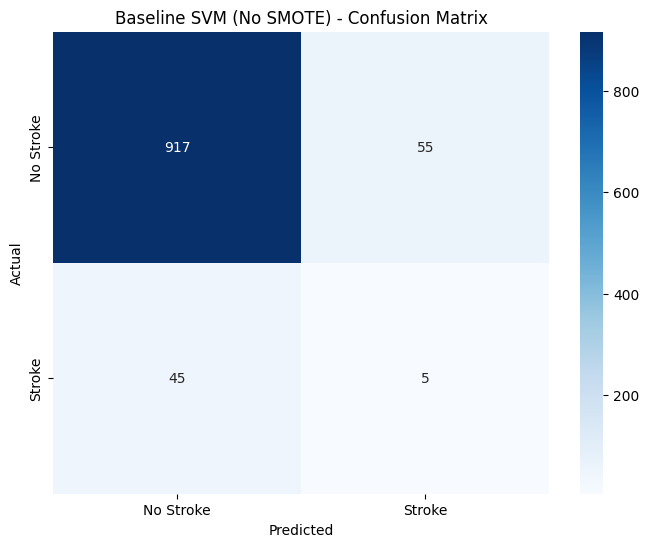

In [33]:
print("Training Baseline SVM (Without SMOTE)...")

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('scale', MinMaxScaler(), ['age', 'avg_glucose_level', 'bmi'])
    ],
    remainder='passthrough'
)

# 1. Define baseline pipeline
baseline_pipeline = Pipeline(steps=[
    ('bmi_imputer', BMIDecisionTreeImputer()),
    ('preprocessor', baseline_preprocessor),
    ('svm', SVC(probability=True, random_state=42))
])

# 2. Define Hyperparameter grid 
param_distributions_svm_base = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1],
}

f2_scorer = make_scorer(fbeta_score, beta=2)

# 3. Setup RandomizedSearchCV
svm_base_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_distributions_svm_base,
    n_iter=20,
    cv=5,
    scoring=f2_scorer,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 4. Fit directly on the IMBALANCED, raw (unscaled, BMI-missing) training data
svm_base_search.fit(X_train, y_train)
best_svm_base = svm_base_search.best_estimator_

# 5. Evaluate on the Unseen Test Data
y_pred_svm_base = best_svm_base.predict(X_test)
y_pred_proba_svm_base = best_svm_base.predict_proba(X_test)[:, 1]

print("\nBest parameters for Baseline SVM:", svm_base_search.best_params_)
print("\n" + "=" * 60)
print("BASELINE SVM EVALUATION (NO SMOTE)")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_base):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm_base):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_svm_base):.4f}")
print(f"F2 Score  : {fbeta_score(y_test, y_pred_svm_base, beta=2):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba_svm_base):.4f}")

# 6. Confusion Matrix Visualization
cm_svm_base = confusion_matrix(y_test, y_pred_svm_base)
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Baseline SVM (No SMOTE) - Confusion Matrix")
plt.show()


# Pipeline: SMOTE + SVM

In [34]:
columns_to_scale = ['age', 'avg_glucose_level', 'bmi']

preprocessor = ColumnTransformer(
    transformers=[
        ('scale', MinMaxScaler(), columns_to_scale)
    ],
    remainder='passthrough'
)

pipeline = ImbPipeline(steps=[
    ('bmi_imputer', BMIDecisionTreeImputer()),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
])

# GridSearchCV over Kernels, C and Gamma

In [35]:
param_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10, 100],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 'auto'],
        'svm__degree': [2, 3, 4]
    },
    {
        'svm__kernel': ['sigmoid'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1]
    },
]

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=f2_scorer,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best kernel/params:", grid_search.best_params_)
print("Best CV F2 score:", grid_search.best_score_)


Fitting 5 folds for each of 55 candidates, totalling 275 fits


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best kernel/params: {'svm__C': 10, 'svm__kernel': 'linear'}
Best CV F2 score: 0.39593048734101033


**Evaluate the best model on the held-out, untouched `X_test`**

In [36]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))


Test Accuracy: 0.7172211350293543

              precision    recall  f1-score   support

           0       0.99      0.71      0.83       972
           1       0.13      0.82      0.22        50

    accuracy                           0.72      1022
   macro avg       0.56      0.77      0.52      1022
weighted avg       0.95      0.72      0.80      1022



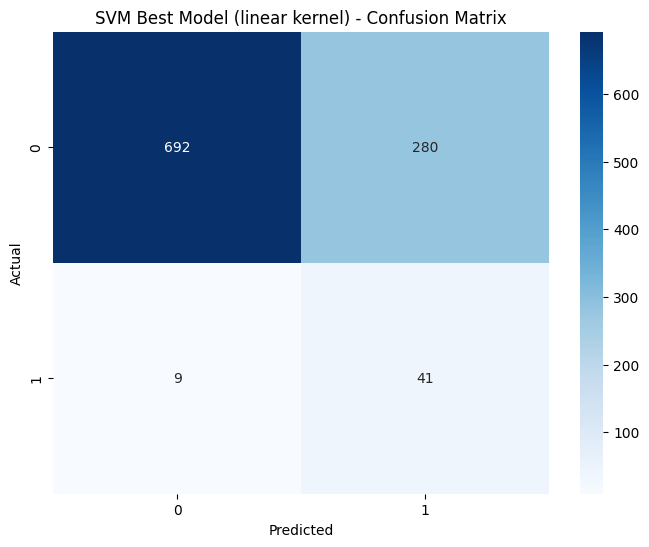

In [37]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f"SVM Best Model ({grid_search.best_params_['svm__kernel']} kernel) - Confusion Matrix")
plt.show()


**Evaluation Metrics**

In [38]:
print("=" * 60)
print("MODEL EVALUATION ON UNSEEN TEST DATA")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"F2 Score : {fbeta_score(y_test, y_pred, beta=2):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")


MODEL EVALUATION ON UNSEEN TEST DATA
Accuracy : 0.7172
Precision: 0.1277
Recall   : 0.8200
F1 Score : 0.2210
F2 Score : 0.3935
ROC-AUC  : 0.8392


**ROC-AUC & Percision-Recall Curve**

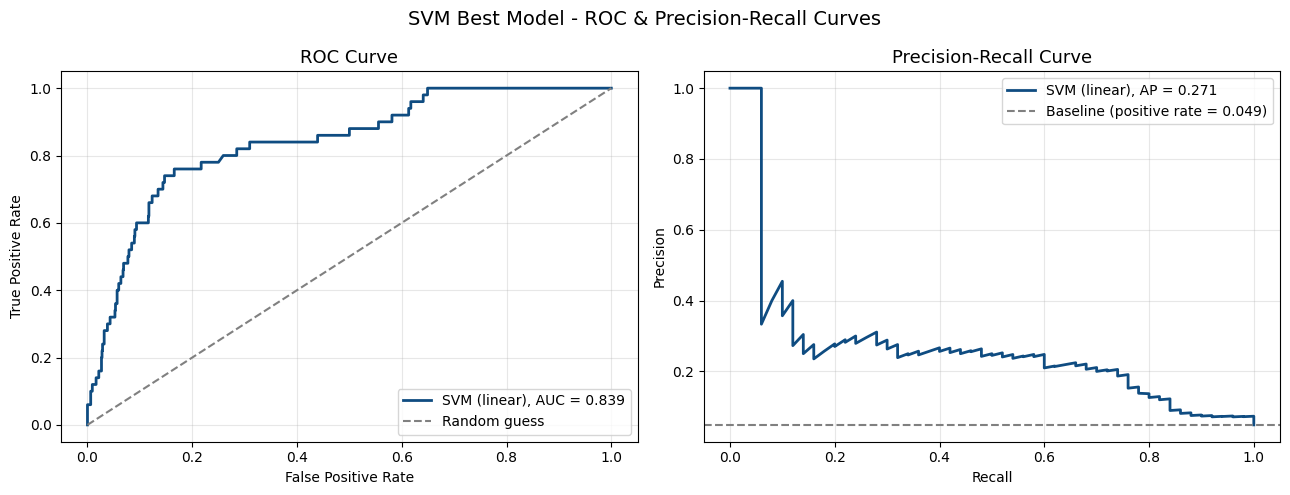

ROC-AUC: 0.8392
PR-AUC (Average Precision): 0.2711


In [39]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Precision-Recall curve
precisions, recalls, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

# Baseline for PR curve = proportion of positive class in the test set
baseline = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC subplot 
axes[0].plot(fpr, tpr, color="#0f4c81", linewidth=2,
             label=f"SVM ({grid_search.best_params_['svm__kernel']}), AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
axes[0].set_title("ROC Curve", fontsize=13)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.3)

# Precision-Recall subplot 
axes[1].plot(recalls, precisions, color="#0f4c81", linewidth=2,
             label=f"SVM ({grid_search.best_params_['svm__kernel']}), AP = {pr_auc:.3f}")
axes[1].axhline(baseline, linestyle="--", color="gray", label=f"Baseline (positive rate = {baseline:.3f})")
axes[1].set_title("Precision-Recall Curve", fontsize=13)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.suptitle("SVM Best Model - ROC & Precision-Recall Curves", fontsize=14)
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc:.4f}")


**Feature Importance**

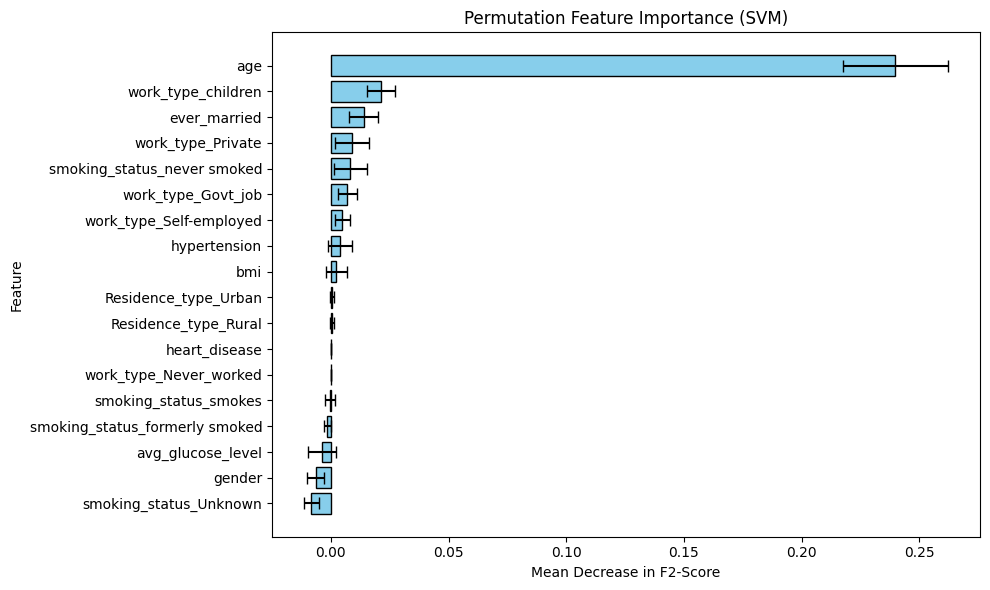

In [40]:
perm_results = permutation_importance(
    best_model, 
    X_test, 
    y_test, 
    scoring=f2_scorer, 
    n_repeats=10, 
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_results.importances_mean,
    "Importance_Std": perm_results.importances_std
})

perm_importance_df = perm_importance_df.sort_values(by="Importance_Mean", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))

plt.barh(
    perm_importance_df["Feature"][::-1], 
    perm_importance_df["Importance_Mean"][::-1], 
    xerr=perm_importance_df["Importance_Std"][::-1], 
    capsize=4, 
    color='skyblue',
    edgecolor='black'
)

plt.xlabel("Mean Decrease in F2-Score")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance (SVM)")
plt.tight_layout()

plt.show()

## Kernel Comparison (from GridSearchCV results)

In [41]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['kernel'] = results_df['param_svm__kernel']

best_per_kernel = (
    results_df.loc[results_df.groupby('kernel')['mean_test_score'].idxmax()]
    [['kernel', 'mean_test_score', 'params']]
    .rename(columns={'mean_test_score': 'best_cv_f2'})
    .sort_values('best_cv_f2', ascending=False)
    .reset_index(drop=True)
)
best_per_kernel


,kernel,best_cv_f2,params
0,linear,0.395930,"{'svm__C': 10, 'svm__kernel': 'linear'}"
1,rbf,0.395284,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne..."
2,sigmoid,0.390170,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne..."
3,poly,0.384531,"{'svm__C': 1, 'svm__degree': 2, 'svm__gamma': ..."


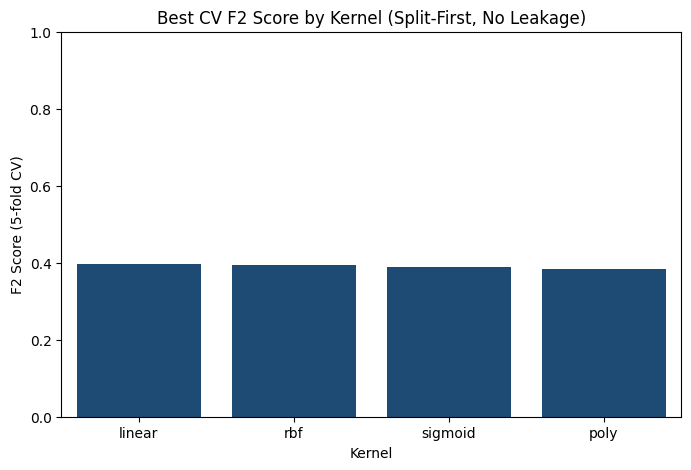

In [42]:
plt.figure(figsize=(8,5))
sns.barplot(data=best_per_kernel, x='kernel', y='best_cv_f2', color="#0f4c81")
plt.title('Best CV F2 Score by Kernel (Split-First, No Leakage)')
plt.ylabel('F2 Score (5-fold CV)')
plt.xlabel('Kernel')
plt.ylim(0, 1)
plt.show()


In [43]:
# Export the FULL pipeline (Handles its own scaling, skips SMOTE automatically)
joblib.dump(grid_search.best_estimator_, 'stroke_svm_model.pkl', compress=3)

# Export the exact columns this specific SVM expects
joblib.dump(list(X_train.columns), 'svm_columns.pkl')

# pipeline's 'preprocessor' step, so its learned min/max values are identical to the ones
# actually used inside grid_search.best_estimator_ during training/prediction.
scaler = grid_search.best_estimator_.named_steps['preprocessor'].named_transformers_['scale']
joblib.dump(scaler, 'svm_scaler.pkl')

print("SVM Pipeline and columns saved successfully!")

SVM Pipeline and columns saved successfully!
